In [7]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks')
try:
    from multiclass_functions2_8 import *
except ModuleNotFoundError:
    print("Module 'multiclass_functions2_8' not found. Please check the file name and location.")
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import copy
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cpu


In [8]:
BATCH_SIZE = 64
LR = 2e-3
LR_STEP= 3
LR_GAMMA= 0.9
EPOCH= 10
TRAIN_RATIO= 0.8
criterion = nn.CrossEntropyLoss()
# transform_test = transforms.Compose([transforms.ToTensor()])
new_model_train = True
model_type = "CNN_deep"
dataset = "STL10"
save_model_path = f"/content/drive/MyDrive/Colab Notebooks/results/{model_type}_{dataset}.pt"
save_history_path = f"/content/drive/MyDrive/Colab Notebooks/results/{model_type}_history_{dataset}.pt"

In [9]:
def to_uint8(x):
    return (255*x).type(torch.uint8)

In [10]:
transform_train = transforms.Compose([
    transforms.ToTensor(),

    # transforms.Lambda(to_uint8),
    # to_uint8, # 가능
    # transforms.Lambda(lambda x:(255*x).type(torch.uint8)),
    # lambda x:(255*x).type(torch.uint8), # 가능
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    # (아마도) 이미지넷 데이터 전체 픽셀에 대해서 구한 평균, std 값

    # transforms.Resize(size=(20,20)), # size는 (height,width)
    # transforms.CenterCrop(size=(20,20)), # size 는 (height, width)
    # transforms.Pad(6), # 20+6*2 = 32
    # transforms.RandomApply(nn.ModuleList([transforms.CenterCrop(size=(20,20)),
    #                                       transforms.Pad(6)]), p=0.5), # ModuleList 안해도 되더라
    # transforms.RandomCrop(size=(20,20)), # 어디를 자를지 random 하게 자름
    # transforms.RandomResizedCrop(size=(20,20), scale=(0.3,1), ratio=(0.3,1.7)),
    # random 하게 자른 다음에 resize라서 RandomCrop과 다름
    # scale은 어느 정도로 작은 범위를 자를지 (0~1 사이 값)
    # ratio는 aspect ratio로, 가로 길이/세로 길이 를 의미한다.
    # (a,b) <- a 와 b 사이 값을 uniform random 하게 뽑아요

    # transforms.RandomGrayscale(p=0.5), # gray로 바꾸는 데, 출력 채널 수를 3으로 유지
    # transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.5, hue=0.15),
    # 밝기, 대비, 채도, 색조가 센서마다 다를 수 있음을 고려 (number: percentage to convert)
    # 밝기(brightness)를 키우면 밝은 부분에서 saturation이 일어나면서, HDR이 낮은 센서에 대응 가능
    # 대비(contrast) augmentation은 HDR이 서로 다른 센서에 대응 가능
    # 채도(saturation) 및 색조(hue) augmentation은 ISP에서 color correction matrix 값이 센서마다 서로 다른 경우 등,
    # 색 표현이 다른 센서에 대응 가능
    # transforms.RandomAutocontrast(p=0.5), # p의 확률로 대비를 자동 조정
    # transforms.RandomEqualize(p=0.5), # p의 확률로 R,G,B histogram을 일치시킴 (이건 uint8로 되어있는 이미지만 가능)
    # transforms.RandomInvert(p=0.5), # p의 확률로 색반전
    # new 픽셀 값 = 최댓 값 - 기존의 픽셀 값 을 통해 반전시킴
    # transforms.RandomSolarize(threshold=200, p=0.5),
    # p의 확률로(즉 그 이미지에 대해 할지 말지 정하고) threshold 넘는 픽셀 값에 대해 inverting
    # transforms.RandomPosterize(bits=3, p=0.5),
    # 픽셀 하나가 가지는 값의 bit수(0~8)를 p의 확률로 bits로 바꿈 (이건 uint8로 되어있는 것만 가능)

    # transforms.GaussianBlur(kernel_size=(5,5), sigma=(0.1,2)),
    # kernel_size = (가로,세로) sigma=(min,max) min ~ max 에서 uniform 하게 하나 뽑음
    # transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    # sharpness_factor = 1 이면 원래 이미지, 0에 가까우면 blur, 1보다 클수록 sharp해짐

    # transforms.RandomHorizontalFlip(p=0.4), # p 확률로 좌우반전
    # transforms.RandomVerticalFlip(p=0.5), # p 확률로 상하반전
    # transforms.RandomRotation(degrees=(0,180)), # 0~180도 랜덤하게 회전
    # transforms.RandomAffine(degrees=(0,30),translate=(0.1,0.3),scale=(0.5,1.2)),
    # translate는 이동하는 정도 (비율), scale은 크기 조절
    # transforms.RandomPerspective(distortion_scale=0.6, p=0.5), # distortion 정도 0~1 사이, default는 0.5, p는 적용 확률

    # transforms.RandomErasing(p=0.5, scale=(0.03,0.3), ratio=(0.3,3.3)),
    # scale: 이미지의 몇 퍼 정도를 지울지
    # ratio: 지우는 영역의 aspect ratio

    # transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    # transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    # transforms.AutoAugment(transforms.AutoAugmentPolicy.SVHN),
    # AutoAugment:Learning Augmentation Strategies from Data 라는 논문에 따른 augmentation (uint8 이여야 함)
    # transforms.RandAugment(),
    # RandAugment: Practical automated data augmentation with a reduced search space 라는 논문에 따른 augmentation (uint8 이여야 함)
    # transforms.TrivialAugmentWide(),
    # TrivialAugment: Tuning-free Yet State-of-the-Art Data Augmentation 라는 논문에 따른 augmentation (uint8)
    # transforms.AugMix(),
    # AugMix: A Simple Data Processing Method to Improve Robustness and Uncertainty 라는 논문에 따른 augmentaiton (uint8)
    ])
transform_test = transforms.ToTensor()

In [5]:
transform = transforms.ToTensor()
train_DS = datasets.STL10(root='/content/drive/MyDrive/Colab Notebooks/data', split='train', download=True, transform=transform)
NoT = int(len(train_DS)*TRAIN_RATIO); NoV = len(train_DS) - NoT
train_DS, val_DS = torch.utils.data.random_split(train_DS, [NoT, NoV])
val_DS.transform = transform_test
test_DS = datasets.STL10(root='/content/drive/MyDrive/Colab Notebooks/data', split='test', download=True, transform=transform)

train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = torch.utils.data.DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=False)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


In [11]:
# # Albumentation 쓸 때만 주석 해제

# transform_train = A.Compose([
#     A.Resize(20,20),
#     A.HorizontalFlip(p=0.5),
#     A.VerticalFlip(p=0.5),

#     A.ShiftScaleRotate(shift_limit=(-0.05,0.05), scale_limit=(0,0), rotate_limit=(-10,10), p=0.7, border_mode=cv2.BORDER_CONSTANT),
#     A.RandomResizedCrop(height=20, width=20, scale=(0.3, 1), ratio=(0.75, 1.33), p=0.7),

#     A.RandomBrightnessContrast(briㅁghtness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), p=0.8),

#     A.OneOf([
#              A.ElasticTransform(p=1, sigma=30, alpha=10, alpha_affine=5),
#              #  sigma는 간격, alpha는 꼬불한 정도, alpla_affine은 affine transform의 정도
#              A.GridDistortion(p=1), # grid로 쪼갠다음 각 patch들을 짜부시킴
#              A.OpticalDistortion(p=1,distort_limit=1, shift_limit=0.5),
#              #  distort_limit 가운데 부분이 볼록 튀어나와 보이는 정도 (0~1), shift_limit은 어느정도 이미지를 밀건지 (0~1)
#              ], p=1),

#     # A.Normalize(), # 애는 default가 0~255인 이미지가 들어오는 것으로 되어있어서 normalize 먼저
#     ToTensorV2()])

# transform_test = ToTensorV2() # unit8, 0~255는 그대로, Tensor, 개채행열로만 바꿔줌

# class CIFAR10_custom(datasets.CIFAR10):
#     def __init__(self, root="/content/drive/MyDrive/Colab Notebooks/data", train=True, download=True, transform=None):
#         super().__init__(root=root, train=train, download=download, transform=transform)

#     def __getitem__(self, index):
#         image = self.data[index]
#         label = self.targets[index]

#         if self.transform is not None:
#             transformed = self.transform(image=image) # self.transform(image=image, mask=mask)
#             image = transformed["image"]
#             # mask = transformed["mask"]

#         return image, label

# test_DS = CIFAR10_custom(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform_test)
# test_DL = torch.utils.data.DataLoader(test_DS, batch_size = BATCH_SIZE, shuffle = False)

x_batch size = torch.Size([64, 3, 96, 96])
x_batch size = torch.Size([64, 3, 96, 96])


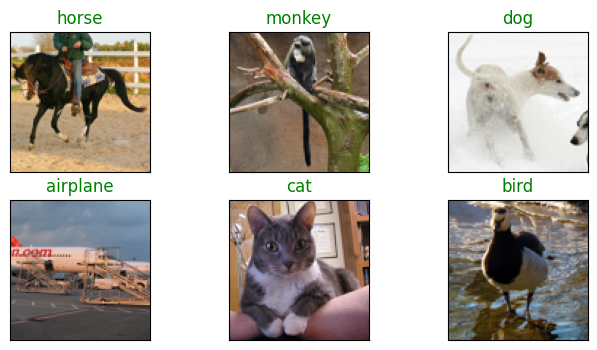

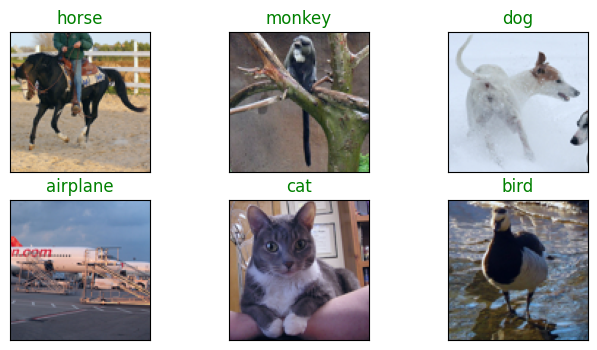

In [12]:
test_DS_wT = copy.deepcopy(test_DS) # wT = with Transform
test_DS_wT.transform = transform_train
test_DL_wT = torch.utils.data.DataLoader(test_DS_wT, batch_size = BATCH_SIZE, shuffle = False)

im_plot(test_DL)
im_plot(test_DL_wT)

In [ ]:
print(train_DS)
print(test_DS)
print(len(train_DS))
print(len(test_DS))

Dataset STL10
    Number of datapoints: 8000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: test
    StandardTransform
Transform: ToTensor()
4000
8000


['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
torch.Size([64, 3, 96, 96])
horse


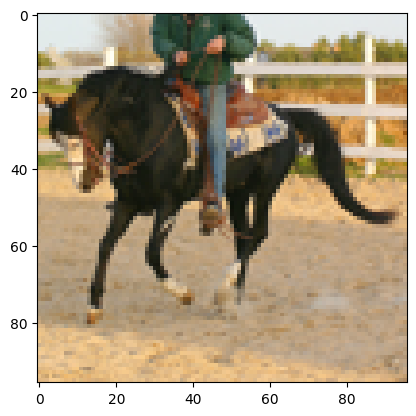

In [ ]:
print(test_DS.classes)
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0)) # 차원 순서 바꾸기
print(test_DS.classes[y_batch[0]])

In [ ]:
# # 1. tensor 로 바꾸고
# # 2. 개채행열로 바꾸고
# # 3. 0~1 사이로 바꾸고 (int -> float)

# print(type(train_DS.data))

# print(train_DS.data.shape)

# print(train_DS.data.dtype)

# print(train_DS.data[0][0][0][0])

# x_batch, y_batch = next(iter(train_DL)) # next(iter(train_DS)) 는 한장만 꺼내기
# print(type(x_batch))
# print(x_batch.shape)
# print(x_batch.dtype)
# print(x_batch[0][0][0][0])

AttributeError: 'Subset' object has no attribute 'data'

In [ ]:
# class MLP(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.linear = nn.Sequential(nn.Linear(3*32*32, 100),
#                                     nn.ReLU(),
#                                     nn.Linear(100,10))

#     def forward(self, x):
#         x = torch.flatten(x, start_dim=1)
#         x = self.linear(x)
#         return x

# class CNN(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.conv1 = nn.Sequential(nn.Conv2d(3,8,3, padding=1),
#                                    nn.BatchNorm2d(8),
#                                    nn.ReLU())
#         self.Maxpool1 = nn.MaxPool2d(2)
#         self.conv2 = nn.Sequential(nn.Conv2d(8,16,3, padding=1),
#                                    nn.BatchNorm2d(16),
#                                    nn.ReLU())
#         self.Maxpool2 = nn.MaxPool2d(2)
#         self.conv3 = nn.Sequential(nn.Conv2d(16,32,3, padding=1),
#                                    nn.BatchNorm2d(32),
#                                    nn.ReLU())
#         self.Maxpool3 = nn.MaxPool2d(2)
#         ##### torch faltten
#         self.fc = nn.Linear(32*4*4, 10)

#     def forward(self, x):
#         x = self.conv1(x)
#         x = self.Maxpool1(x)
#         x = self.conv2(x)
#         x = self.Maxpool2(x)
#         x = self.conv3(x)
#         x = self.Maxpool3(x)
#         x = torch.flatten(x,start_dim=1)
#         x = self.fc(x)
#         return x


class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU(),
                                         nn.Conv2d(32,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)

        self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)

        self.classifier = nn.Sequential(nn.Linear(128*12*12,512),
                                        nn.Linear(512,10))

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x



In [ ]:
exec(f"model = {model_type}().to(DEVICE)")
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

In [ ]:
# def Train(model, train_DL, criterion, optimizer):

#     loss_history =[]
#     NoT = len(train_DL.dataset)

#     model.train() # train mode로 전환
#     for ep in range(EPOCH):
#         rloss = 0 # running loss
#         for x_batch, y_batch in train_DL:
#             x_batch = x_batch.to(DEVICE)
#             y_batch = y_batch.to(DEVICE)
#             # inference
#             y_hat = model(x_batch)
#             # loss
#             loss = criterion(y_hat, y_batch)
#             # update
#             optimizer.zero_grad() # gradient 누적을 막기 위한 초기화
#             loss.backward() # backpropagation
#             optimizer.step() # weight update
#             # loss accumulation
#             loss_b = loss.item() * x_batch.shape[0] # batch loss # BATCH_SIZE를 곱하면 마지막 18개도 32개를 곱하니까..
#             rloss += loss_b # running loss
#         # print loss
#         loss_e = rloss/NoT
#         loss_history += [loss_e]
#         print(f"Epoch: {ep+1}, train loss: {round(loss_e,3)}")
#         print("-"*20)

#     return loss_history

# def Test(model, test_DL):
#     model.eval()
#     with torch.no_grad():
#         rcorrect = 0
#         for x_batch, y_batch in test_DL:
#             x_batch = x_batch.to(DEVICE)
#             y_batch = y_batch.to(DEVICE)
#             # inference
#             y_hat = model(x_batch)
#             # accuracy accumulation
#             pred = y_hat.argmax(dim=1)
#             corrects_b = torch.sum(pred == y_batch).item()
#             rcorrect += corrects_b
#         accuracy_e = rcorrect/len(test_DL.dataset)*100
#     print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({round(accuracy_e,1)} %)")


# def Test_plot(model, test_DL):
#     model.eval()
#     with torch.no_grad():
#         x_batch, y_batch = next(iter(test_DL))
#         x_batch = x_batch.to(DEVICE)
#         y_hat = model(x_batch)
#         pred = y_hat.argmax(dim=1)

#     x_batch = x_batch.to("cpu")

#     plt.figure(figsize=(8,4))
#     for idx in range(6):
#         plt.subplot(2,3, idx+1, xticks=[], yticks=[])
#         plt.imshow(x_batch[idx].permute(1,2,0).squeeze(), cmap="gray")
#         pred_class = test_DL.dataset.classes[pred[idx]]
#         true_class = test_DL.dataset.classes[y_batch[idx]]
#         plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class==true_class else "r")

# # 파라미터 수 구하기
# def count_params(model):
#     num = sum([p.numel() for p in model.parameters() if p.requires_grad])
#     return num


In [ ]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr=LR)
    loss_history = Train(model, train_DL, criterion, optimizer,EPOCH)

    torch.save(model, save_model_path)

    plt.plot(range(1,EPOCH+1),loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.title("Train Loss")
    plt.grid()

In [ ]:
load_model = torch.load(save_model_path, map_location=DEVICE)
# model.state.dict()

In [ ]:
Test(load_model, test_DL)
print(count_params(load_model))

In [ ]:
Test_plot(load_model, test_DL)